In [1]:
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

from modulars.distributions import gen_multinomial_data_shared, lda_posterior_shared_theta
from modulars.utils import (load_config, load_best_multid_reference,
    save_to_csv, load_from_csv, find_best_params,
    stickbreaking_simplex_forward, apply_traj_transform_simplex,
    build_summary_runs_from_scale_results,)
from modulars.plot_rr import (
    plot_simplex_dims, plot_dirichlet_marginals_few_restarts,
    plot_dirichlet_mean_band_rrs, plot_dirichlet_simplex_pdf_zoom,)
from modulars.numpyro_rr_test import run_restart_multid

In [14]:
config_file = "dirichlet_config.json"
config = load_config(config_file)

theta_like = np.array(config["theta_like"], dtype=np.float32)
N = config["N"]
alpha_prior = np.array(config["alpha_prior"], dtype=np.float32)
n_cats = config["n_cats"]
total_count = config["total_count"]
max_iters = 100_000
n_restarts = 20
seed = config.get("seed", 15)
shared = config.get("shared", True)

n_vec = np.full(N, total_count, int)

obs_counts = gen_multinomial_data_shared(theta_like, N, total_count, SEED=seed)
true_post = lda_posterior_shared_theta(obs_counts, total_count, alpha_prior)

best_mean, best_cov, best_std = load_best_multid_reference(config)
results_dir = Path("results")

In [3]:
def model(obs_counts, n_vec, alpha_prior):
    """NumPyro model for Dirichlet-Multinomial"""
    # Sample theta from Dirichlet prior
    theta = numpyro.sample(
        'theta',
        dist.Dirichlet(concentration=jnp.array(alpha_prior))
    )
    
    # Observe multinomial data
    with numpyro.plate('observations', len(obs_counts)):
        numpyro.sample('y',
            dist.Multinomial(
                total_count=n_vec,
                probs=theta
            ),
            obs=obs_counts
        )

In [4]:
results = []
for rr_seed in tqdm(range(n_restarts)):
    results.append(
        run_restart_multid(
            rr_seed,
            model,
            data=None,
            param_name="theta",
            n_iters=max_iters,
            dim=n_cats - 1,
            n_particles=100,
            model_args=(obs_counts, n_vec, alpha_prior),
        )
    )

save_to_csv(results_dir / "numpyro_raw_restarts.csv", results)

  0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
loaded_results = load_from_csv(results_dir / "numpyro_raw_restarts.csv")
summary_runs = build_summary_runs_from_scale_results(
    loaded_results,
    n_cats=n_cats,
    forward_fn=stickbreaking_simplex_forward,
    which="multi",
    n_samples=10_000,
    seed=seed,
)

save_to_csv(results_dir / "numpyro_summary_restarts.csv", summary_runs)

local_best = find_best_params(
    [results_dir / "numpyro_summary_restarts.csv"],
    alpha_prior=alpha_prior,
    obs_counts=obs_counts,
    grad_samps=100,
    seed=seed,
)

18.361488
18.321098
18.333567
18.341843
18.363901
18.330519
18.351305
18.347153
18.350172
18.327589
18.32955
18.334238
18.329329
18.347746
18.326418
18.3418
18.324228
18.355785
18.342253
18.318655


In [7]:
single_means, single_stds, multi_means, multi_stds = apply_traj_transform_simplex(
    loaded_results,
    n_cats=n_cats,
    forward_fn=stickbreaking_simplex_forward,
    n_samples=50_000,
    seed=1,
    NOTEBOOK=True,
)

  0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
save_to_csv(
    results_dir / "numpyro_processed_restarts.csv",
    [(single_means, single_stds, multi_means, multi_stds)],
)


# loading results after

In [9]:
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

from modulars.distributions import gen_multinomial_data_shared, lda_posterior_shared_theta
from modulars.utils import (load_config, load_best_multid_reference, load_from_csv, find_best_params)
from modulars.plot_rr import (
    plot_simplex_dims, plot_dirichlet_marginals_few_restarts, plot_dirichlet_simplex_pdf_zoom,)
config_file = "dirichlet_config.json"
config = load_config(config_file)

theta_like = np.array(config["theta_like"], dtype=np.float32)
N = config["N"]
alpha_prior = np.array(config["alpha_prior"], dtype=np.float32)
n_cats = config["n_cats"]
total_count = config["total_count"]
max_iters = 100_000
n_restarts = 20
seed = config.get("seed", 20)
shared = config.get("shared", True)

n_vec = np.full(N, total_count, int)

obs_counts = gen_multinomial_data_shared(theta_like, N, total_count, SEED=seed)
true_post = lda_posterior_shared_theta(obs_counts, total_count, alpha_prior)

best_mean, best_cov, best_std = load_best_multid_reference(config)
results_dir = Path("results")
local_best = find_best_params(
    [results_dir / "numpyro_summary_restarts.csv"],
    alpha_prior=alpha_prior,
    obs_counts=obs_counts,
    grad_samps=100,
    seed=seed,
)

18.361488
18.321098
18.333567
18.341843
18.363901
18.330519
18.351305
18.347153
18.350172
18.327589
18.32955
18.334238
18.329329
18.347746
18.326418
18.3418
18.324228
18.355785
18.342253
18.318655


In [10]:
loaded_processed = load_from_csv(results_dir / "numpyro_processed_restarts.csv")[0]
single_means, single_stds, multi_means, multi_stds = loaded_processed


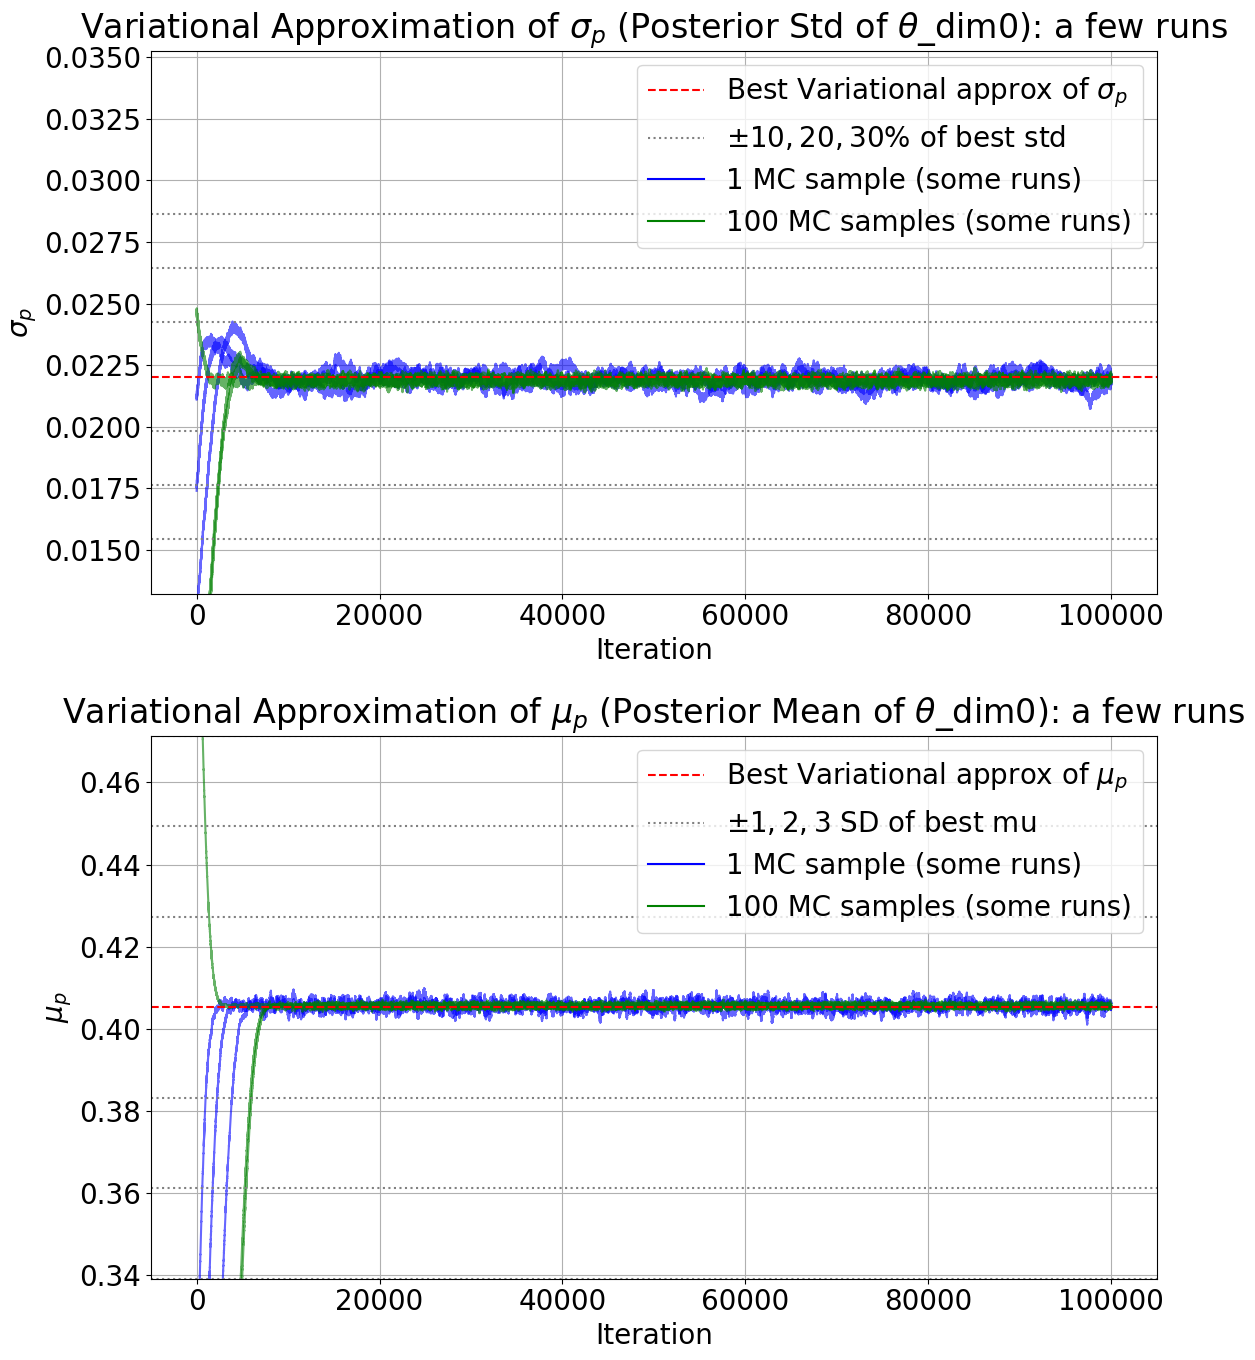

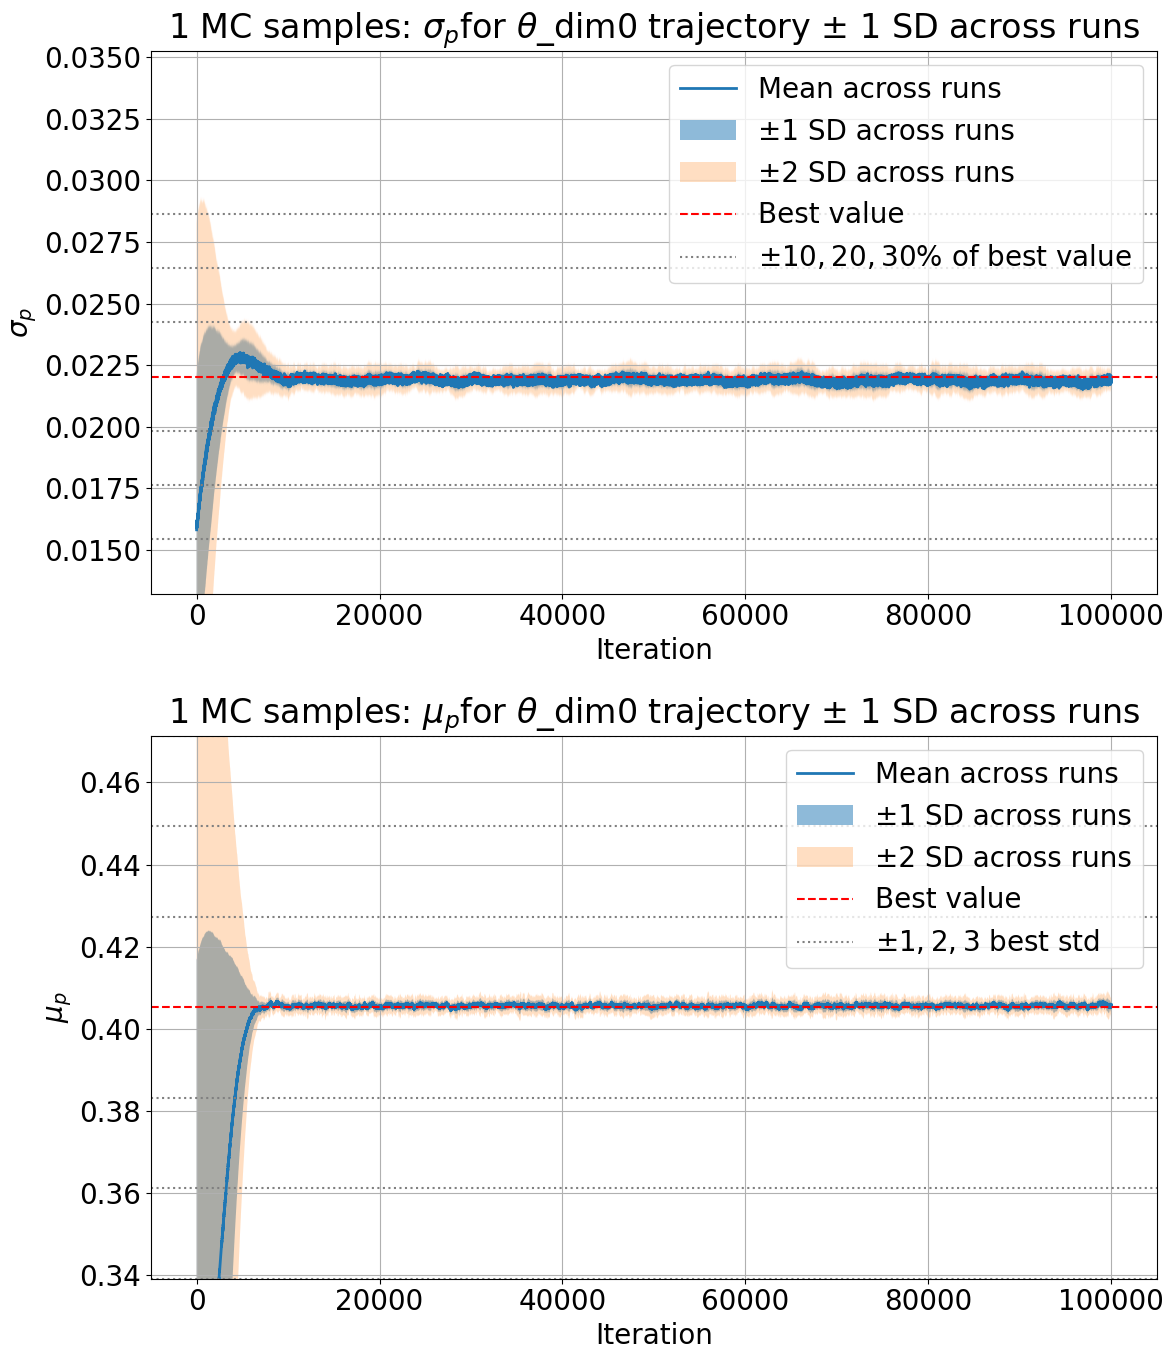

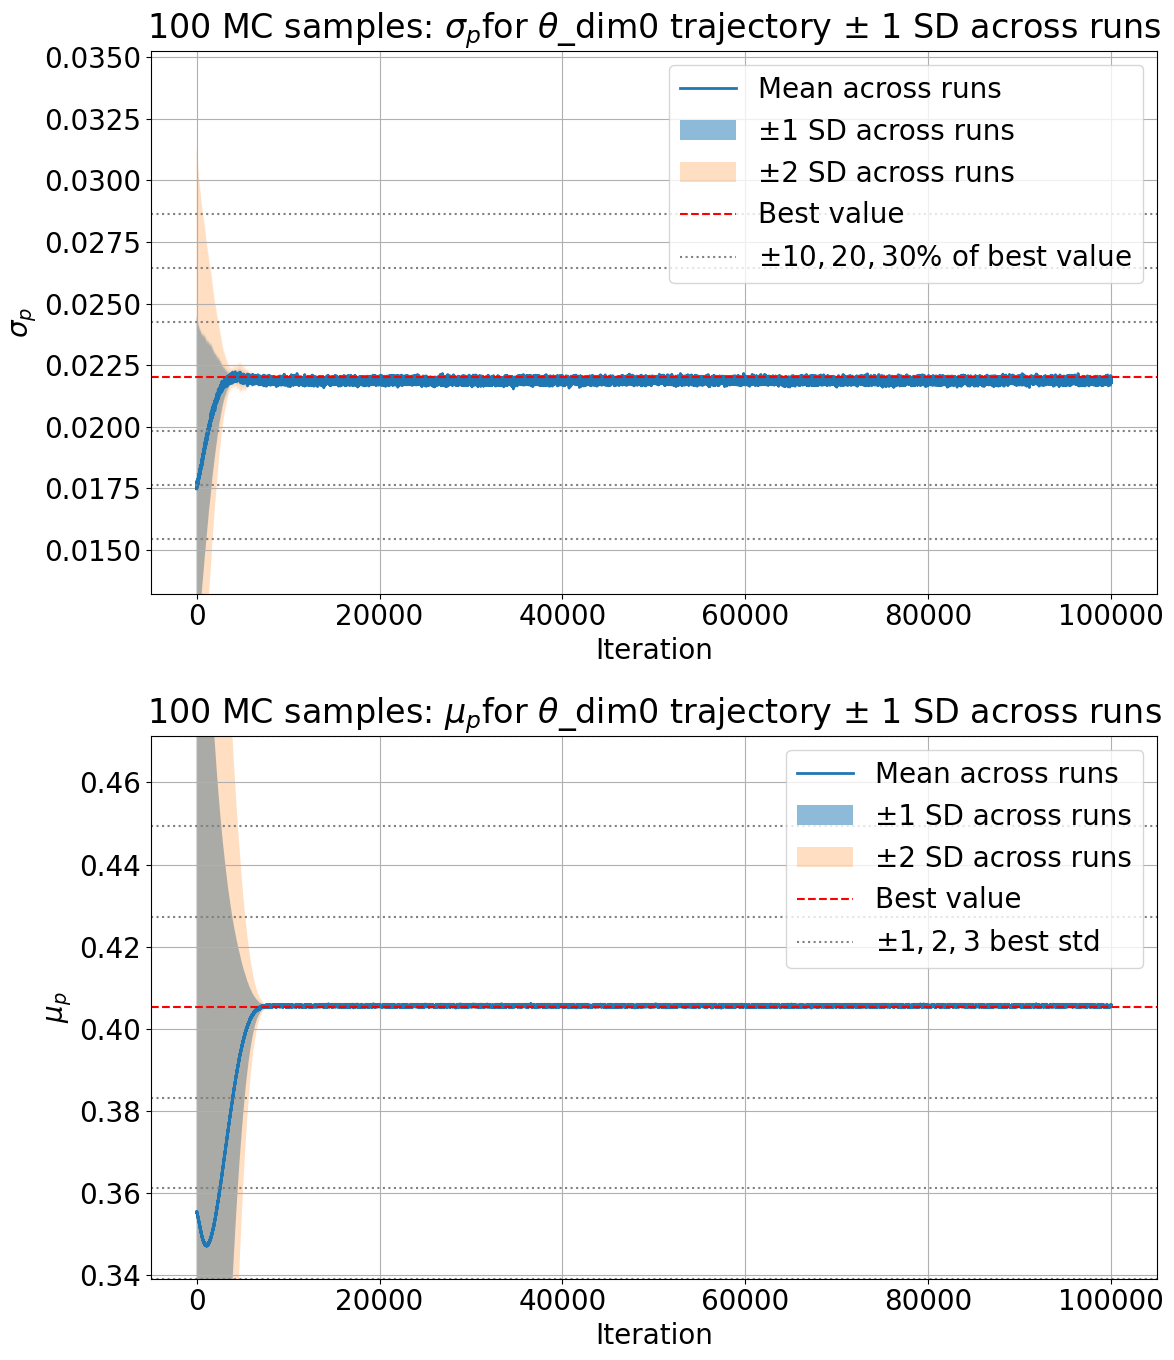

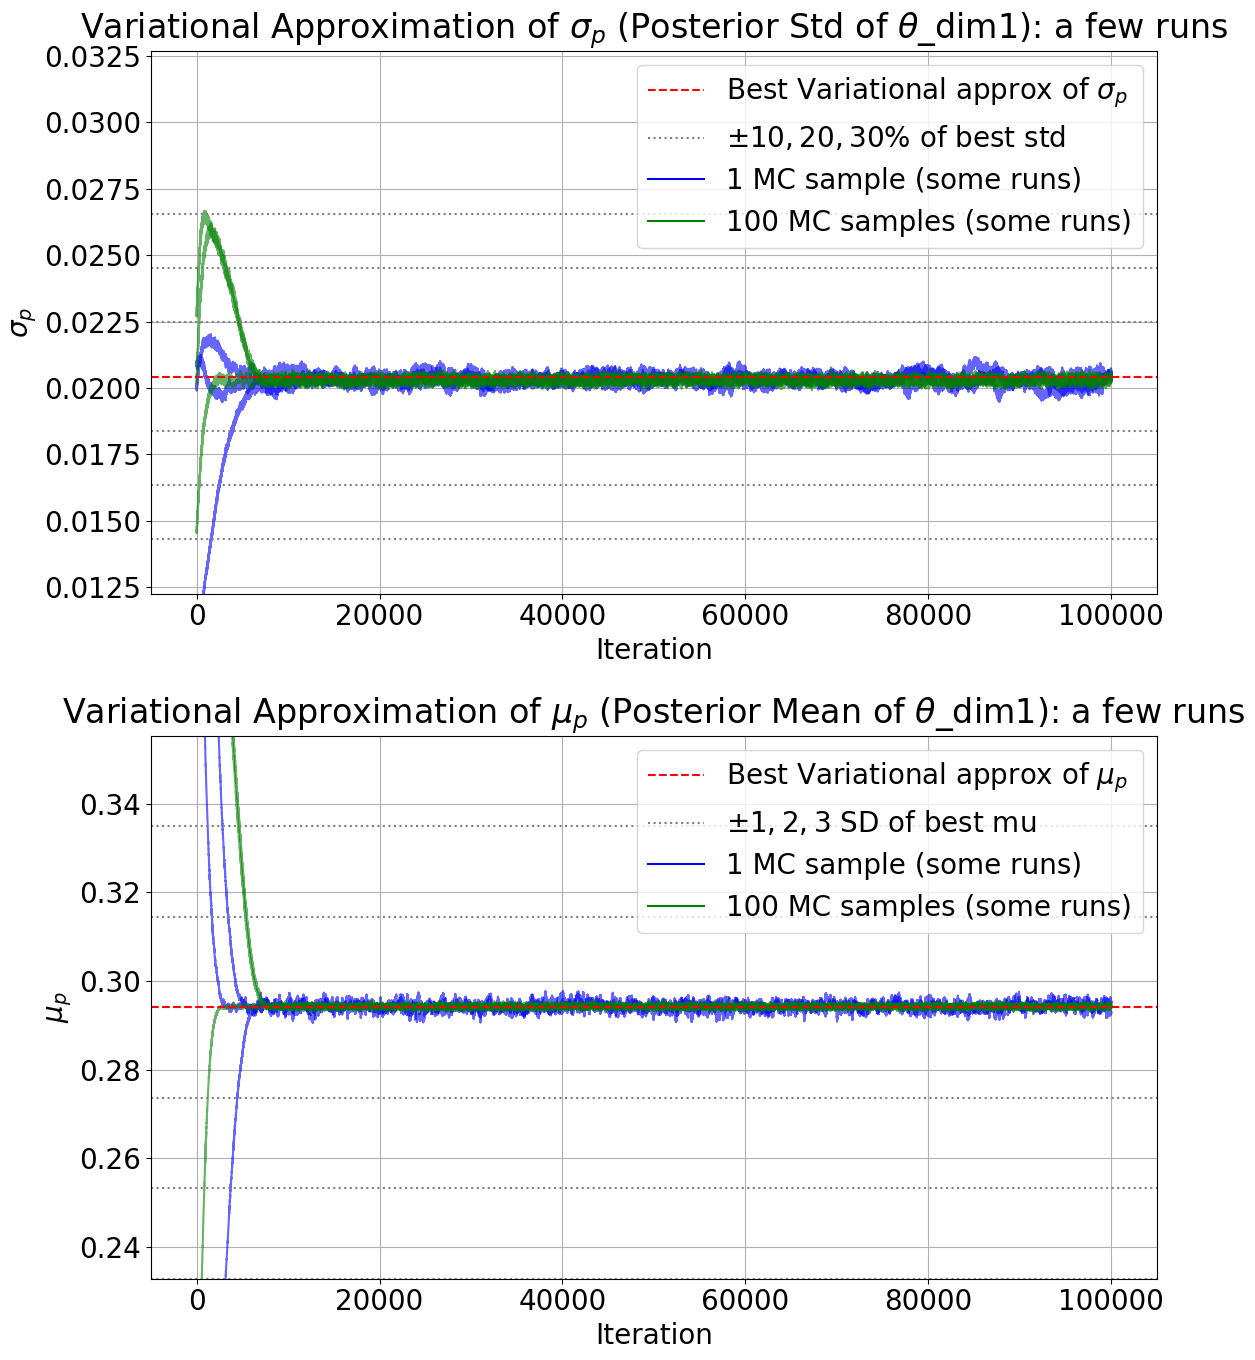

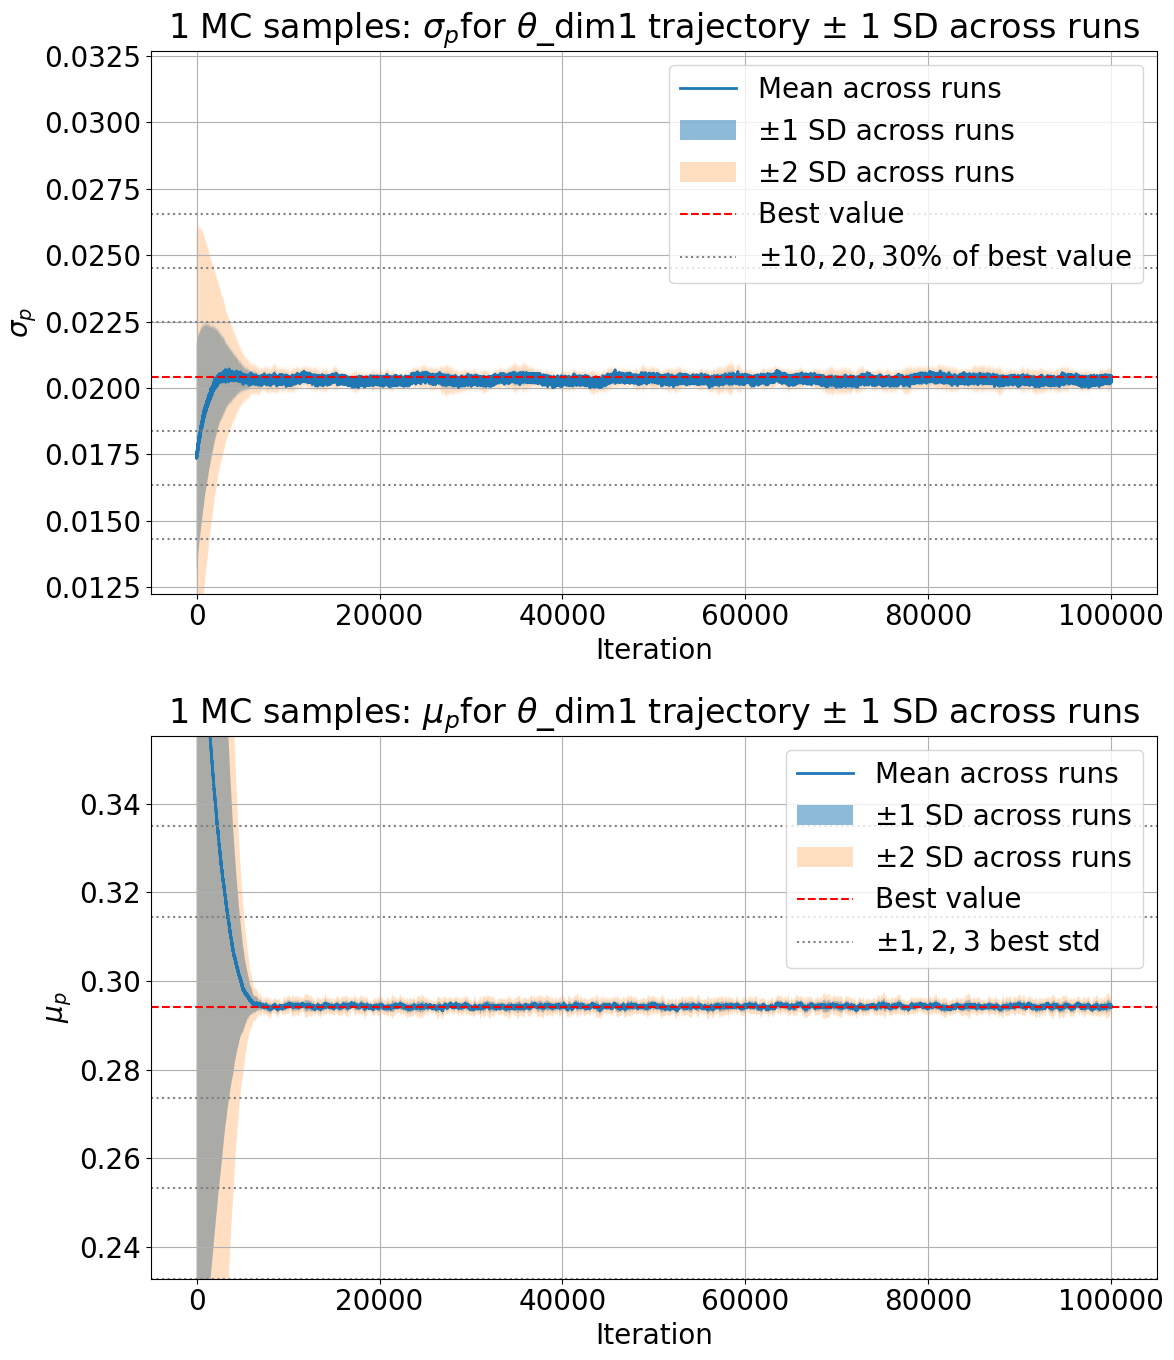

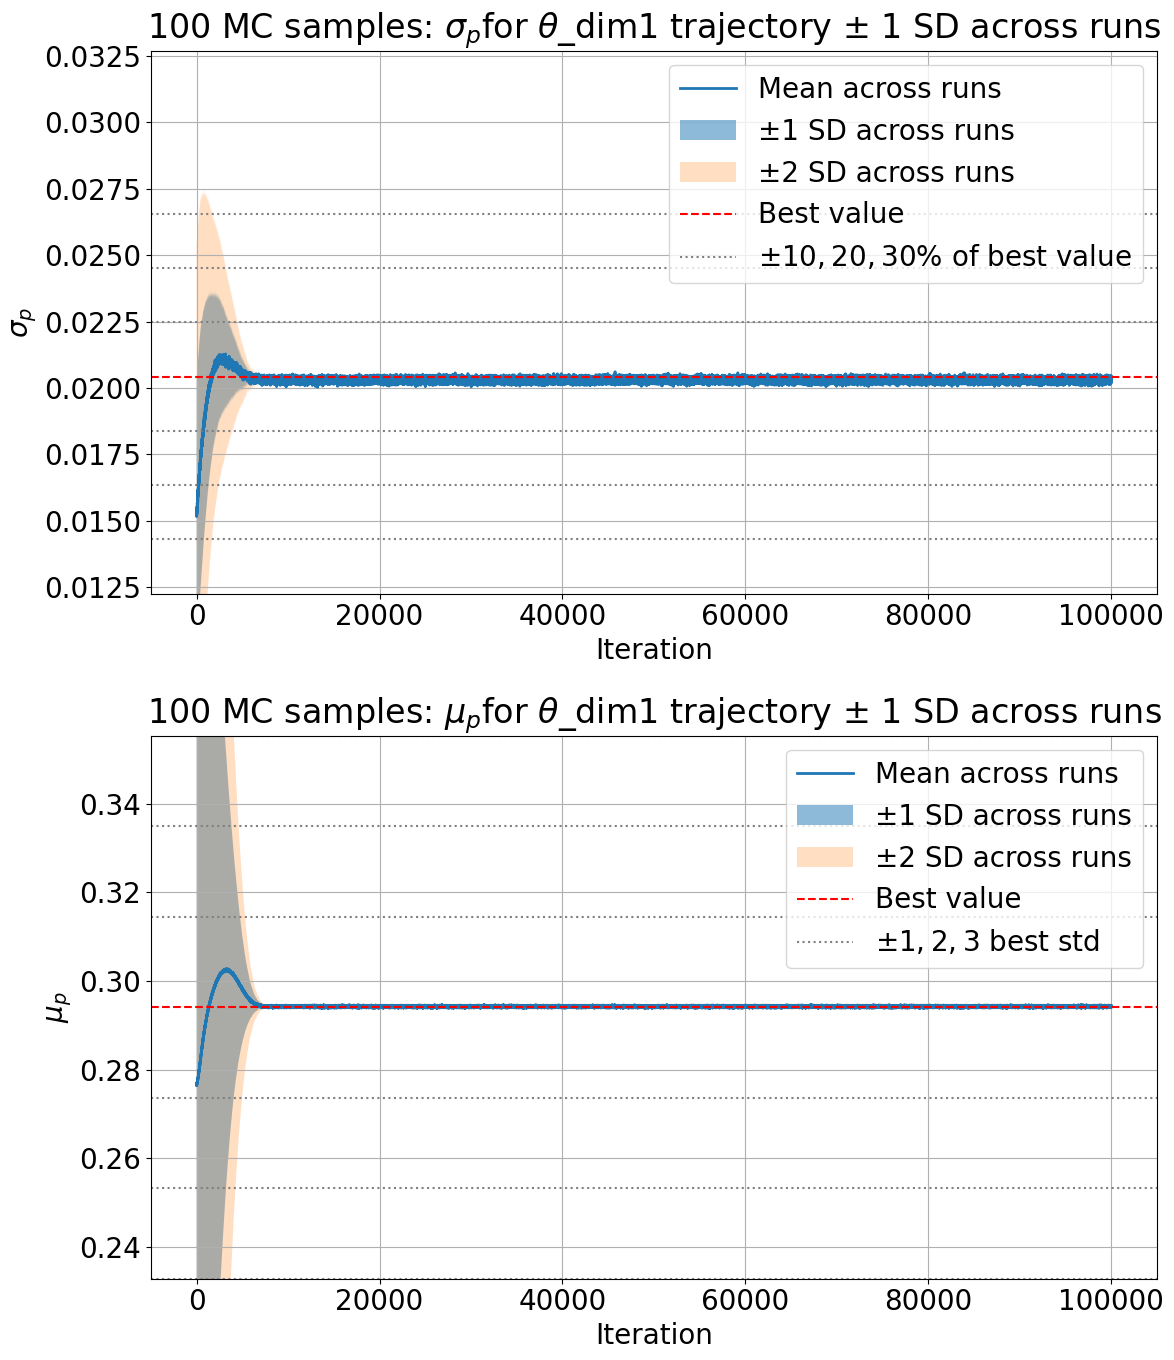

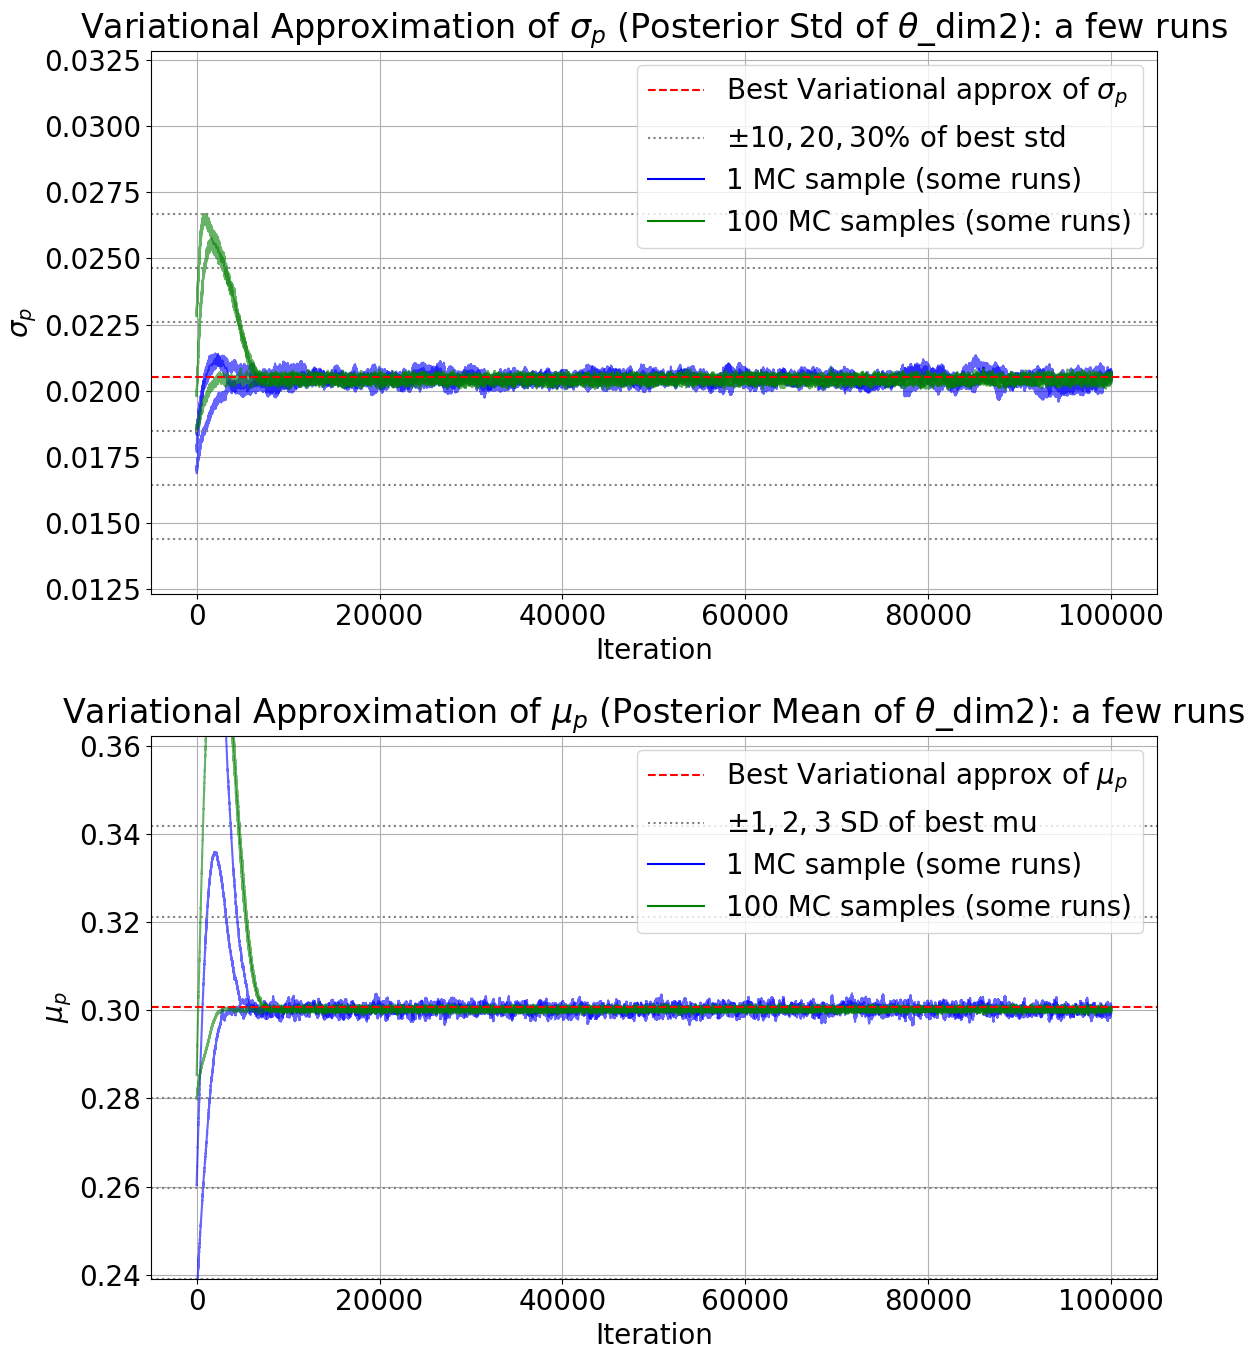

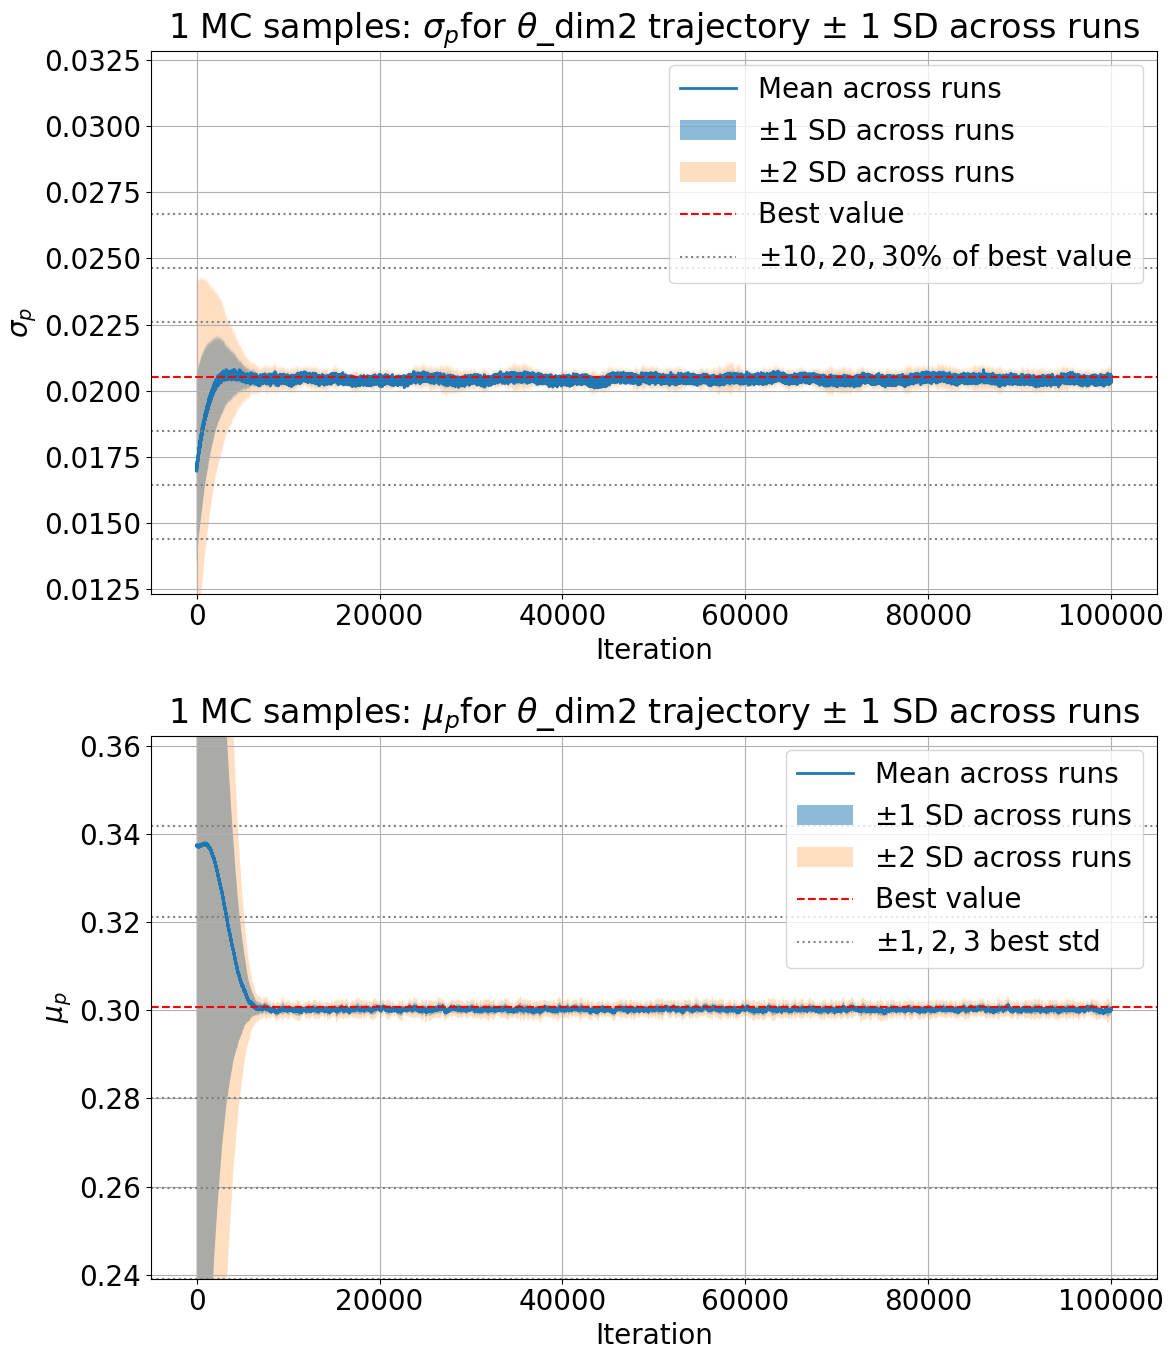

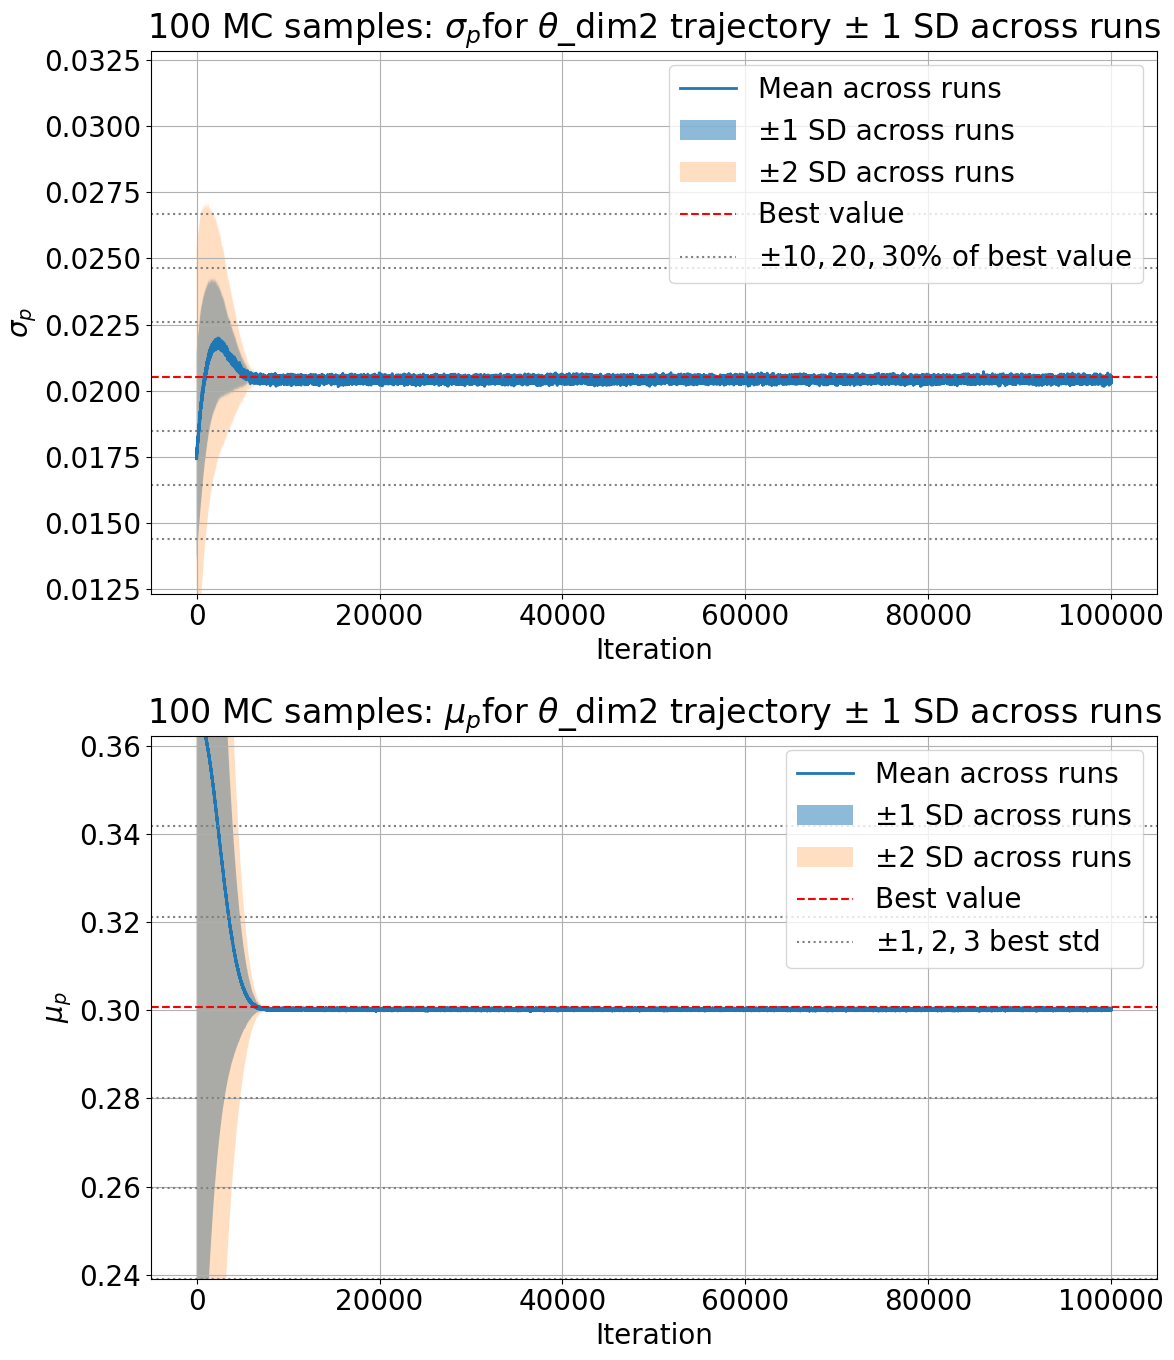

In [15]:
plot_simplex_dims(
    single_means,
    single_stds,
    multi_means,
    multi_stds,
    best_mean,
    best_cov,
    param_name=r"$\theta$",
    which_dims=list(range(n_cats)),
    k=min(3, n_restarts), WITH_STDS=True
)

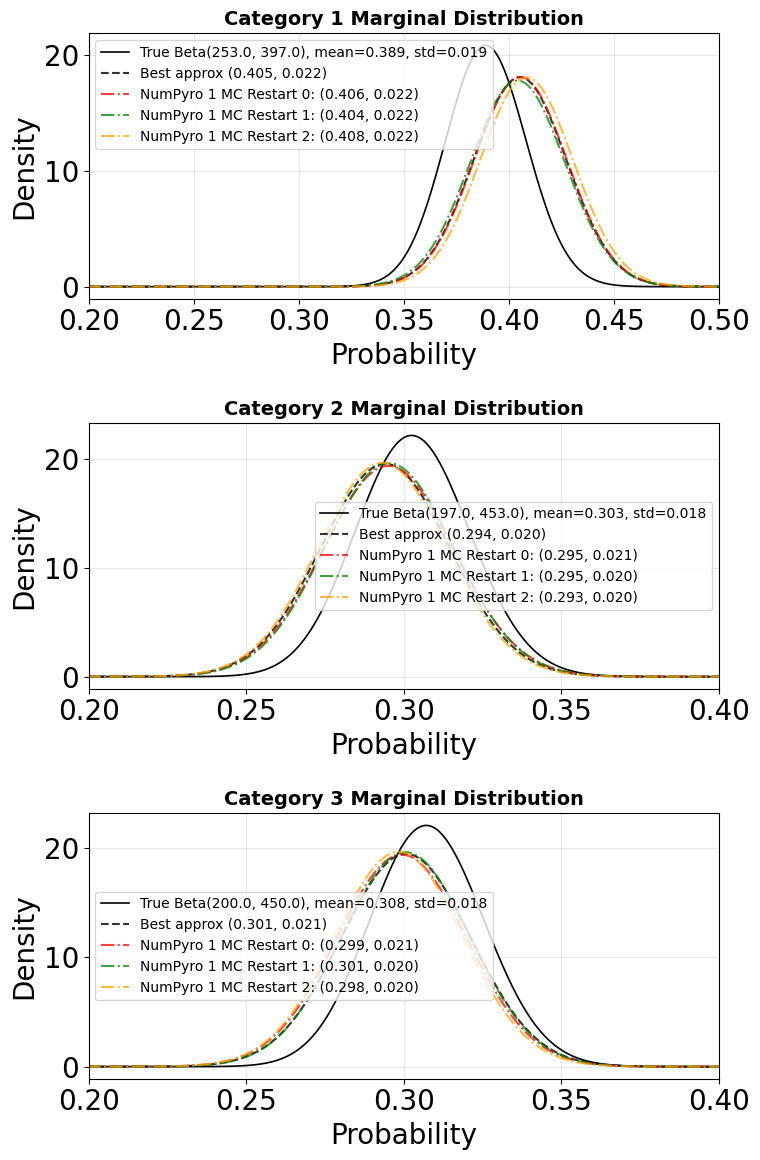

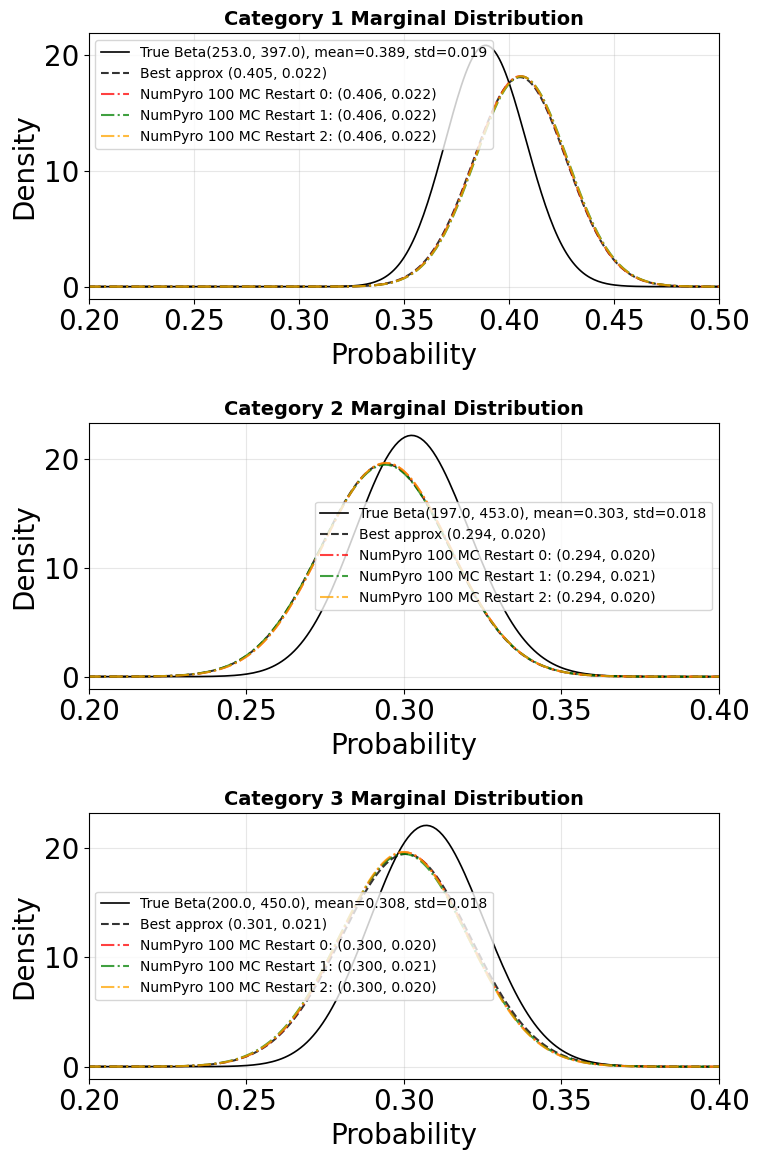

In [16]:
plot_dirichlet_marginals_few_restarts(
    single_means,
    single_stds,
    true_alpha_post=true_post["alpha_post"],
    true_mu_post=true_post["mean_post"],
    true_sigma_post=true_post["std_post"],
    best_mean=best_mean,
    best_cov=best_cov,
    which_restarts=list(range(min(3, n_restarts))),
    iteration=-1,
    label_prefix="NumPyro 1 MC ",
    lims = [(0.2, 0.5), (0.2, 0.4), (0.2, 0.4)]
)

plot_dirichlet_marginals_few_restarts(
    multi_means,
    multi_stds,
    true_alpha_post=true_post["alpha_post"],
    true_mu_post=true_post["mean_post"],
    true_sigma_post=true_post["std_post"],
    best_mean=best_mean,
    best_cov=best_cov,
    which_restarts=list(range(min(3, n_restarts))),
    iteration=-1,
    label_prefix="NumPyro 100 MC ",
    lims = [(0.2, 0.5), (0.2, 0.4), (0.2, 0.4)]
)

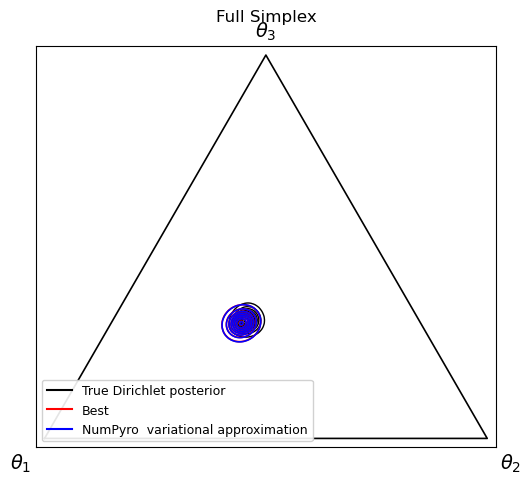

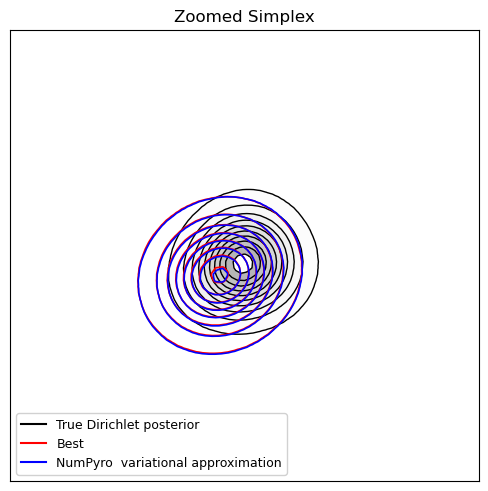

In [17]:
if n_cats == 3:
    plot_dirichlet_simplex_pdf_zoom(
        true_alpha_post=true_post["alpha_post"],
        best_mean=best_mean,
        best_cov=best_cov,
        overlay_mean=local_best["best_mean"],
        overlay_cov=local_best["best_cov"],
        framework_name="NumPyro ",
        fig_size=(2, 3),
    )